# Analise de Acidentes nas Rodovias Federais

**Autores:** Chrysthyan Matheus e Eric Gabriel

Notebook oficial da disciplina de Programacao para Analise de Dados. O objetivo e organizar a leitura, validacao, conversao, processamento em grandes volumes, comparacao de desempenho entre bibliotecas e processamento paralelo distribuido com Dask sobre dados de acidentes em rodovias federais.

A base utilizada vem dos Dados Abertos da Policia Rodoviaria Federal (PRF), especificamente os arquivos CSV de acidentes agrupados por pessoa, com todas as causas e tipos de acidentes, armazenados em `data/raw/`.


In [1]:
import os
import sys
import glob
import textwrap
from datetime import datetime
from pathlib import Path

import pandas as pd
import polars as pl
import pyarrow.compute as pc
import pyarrow.dataset as ds
import dask.dataframe as dd
from dask.distributed import Client, LocalCluster
import matplotlib.pyplot as plt
import seaborn as sns

# Caminhos do projeto.
# A deteccao abaixo permite executar o notebook pela raiz do projeto ou pela pasta notebooks/.
BASE_DIR = Path.cwd()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

RAW_DATA_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DATA_DIR = BASE_DIR / "data" / "processed"
REPORTS_DIR = BASE_DIR / "reports"
PARQUET_DIR = PROCESSED_DATA_DIR / "dados_otimizados"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Permite importar os modulos locais em src/ mesmo quando o notebook e aberto pela pasta notebooks/.
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from src.etl.schema import (
    DATE_COLUMNS,
    SCHEMA_PANDAS,
    TIME_COLUMNS,
    columns_to_read,
    validate_dataframe_quality,
    validate_required_columns,
)
from src.utils.benchmark import conversion_size_report, measure_seconds
from src.utils.plotting import apply_dark_theme, save_report_figure


## 1 - Definicao e validacao dos schemas

Nesta etapa os CSVs brutos sao lidos com tipos definidos explicitamente. A leitura tipada funciona como uma primeira validacao pratica: se uma coluna esperada estiver ausente ou possuir valores incompatíveis com o tipo definido, a etapa de carga/conversao falha e o erro e registrado na saida da celula.

Para deixar a validacao mais formal, o notebook tambem gera relatorios de colunas ausentes, tipos encontrados, valores nulos e valores invalidos. Esses relatorios ajudam a comprovar que o schema foi aplicado e que os dados principais estao consistentes antes da analise.

Os arquivos convertidos sao salvos em Parquet na pasta `data/processed/dados_otimizados/`, preservando os CSVs originais em `data/raw/`.


In [2]:
# Pasta de saida dos arquivos Parquet gerados a partir dos CSVs brutos.
pasta_saida = PARQUET_DIR
os.makedirs(pasta_saida, exist_ok=True)


In [3]:
# Mapeamento dos CSVs brutos usando a estrutura padronizada do projeto.
caminho_busca = str(RAW_DATA_DIR / "*.csv")
arquivos_csv = sorted(glob.glob(caminho_busca))

print(f"Encontrei {len(arquivos_csv)} arquivos CSV em {RAW_DATA_DIR}!")


Encontrei 9 arquivos CSV em /home/aluno/Downloads/pad_acidentes_prf-main/data/raw!


In [4]:
# Amostra inicial para visualizar as colunas e os tipos originais antes da aplicacao do schema.
primeiro_arquivo = arquivos_csv[0]
df_amostra = pd.read_csv(primeiro_arquivo, sep=";", nrows=1000, encoding="latin1")
df_amostra.info(memory_usage="deep")


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      1000 non-null   int64  
 1   pesid                   959 non-null    float64
 2   data_inversa            1000 non-null   str    
 3   dia_semana              1000 non-null   str    
 4   horario                 1000 non-null   str    
 5   uf                      1000 non-null   str    
 6   br                      996 non-null    float64
 7   km                      996 non-null    str    
 8   municipio               1000 non-null   str    
 9   causa_principal         1000 non-null   str    
 10  causa_acidente          1000 non-null   str    
 11  ordem_tipo_acidente     1000 non-null   int64  
 12  tipo_acidente           1000 non-null   str    
 13  classificacao_acidente  988 non-null    str    
 14  fase_dia                1000 non-null   str    
 15 

In [5]:
# Schema centralizado em src/etl/schema.py para evitar duplicacao entre etapas.
# A coluna horario foi mantida para permitir a granularidade por horas.
meu_schema = SCHEMA_PANDAS
colunas_data = DATE_COLUMNS
colunas_hora = TIME_COLUMNS

print("Schema definido para leitura dos CSVs:")
pd.DataFrame(
    [{"coluna": coluna, "tipo_esperado": tipo} for coluna, tipo in meu_schema.items()]
)


Schema definido para leitura dos CSVs:


,coluna,tipo_esperado
0,id,Int64
1,dia_semana,category
2,uf,category
3,br,string
4,municipio,category
5,causa_acidente,category
6,tipo_acidente,category
7,fase_dia,category
8,condicao_metereologica,category
9,tipo_pista,category


In [6]:
# Validacao formal 1: verifica se as colunas esperadas existem em todos os CSVs.
relatorio_colunas = validate_required_columns(arquivos_csv)
relatorio_colunas.to_csv(REPORTS_DIR / "validacao_colunas_ausentes.csv", index=False)
relatorio_colunas


,arquivo,colunas_esperadas,colunas_ausentes,lista_colunas_ausentes
0,acidentes2017_todas_causas_tipos.csv,17,0,Nenhuma
1,acidentes2018_todas_causas_tipos.csv,17,0,Nenhuma
2,acidentes2019_todas_causas_tipos.csv,17,0,Nenhuma
3,acidentes2020_todas_causas_tipos.csv,17,0,Nenhuma
4,acidentes2021_todas_causas_tipos.csv,17,0,Nenhuma
5,acidentes2022_todas_causas_tipos.csv,17,0,Nenhuma
6,acidentes2023_todas_causas_tipos.csv,17,0,Nenhuma
7,acidentes2024_todas_causas_tipos.csv,17,0,Nenhuma
8,acidentes2025_todas_causas_tipos.csv,17,0,Nenhuma


In [7]:
# Conversao dos CSVs para Parquet com schema aplicado.
# Cada arquivo anual e lido, validado pela tipagem e salvo separadamente para facilitar leitura colunar depois.
for arquivo in arquivos_csv:
    ano = Path(arquivo).stem.replace("acidentes", "")[:4]
    print(f"[{ano}] Lendo CSV e aplicando schema...")

    try:
        colunas_para_ler = columns_to_read(arquivo)

        df = pd.read_csv(
            arquivo,
            sep=";",
            encoding="latin1",
            dtype=meu_schema,
            parse_dates=colunas_data,
            usecols=colunas_para_ler,
        )

        # Campo derivado usado nas analises por hora. Ele combina a data e o horario original.
        if "horario" in df.columns:
            df["data_hora"] = pd.to_datetime(
                df["data_inversa"].dt.strftime("%Y-%m-%d") + " " + df["horario"].astype(str),
                errors="coerce",
            )

        nome_saida = pasta_saida / f"acidentes_{ano}.parquet"
        df.to_parquet(nome_saida, engine="pyarrow", index=False)
        print(f"[{ano}] Sucesso! Parquet salvo em {nome_saida.name}.\n")

    except Exception as e:
        print(f"[{ano}] ERRO no arquivo {arquivo}:\n{e}\n")


[2017] Lendo CSV e aplicando schema...
[2017] Sucesso! Parquet salvo em acidentes_2017.parquet.

[2018] Lendo CSV e aplicando schema...
[2018] Sucesso! Parquet salvo em acidentes_2018.parquet.

[2019] Lendo CSV e aplicando schema...
[2019] Sucesso! Parquet salvo em acidentes_2019.parquet.

[2020] Lendo CSV e aplicando schema...
[2020] Sucesso! Parquet salvo em acidentes_2020.parquet.

[2021] Lendo CSV e aplicando schema...
[2021] Sucesso! Parquet salvo em acidentes_2021.parquet.

[2022] Lendo CSV e aplicando schema...
[2022] Sucesso! Parquet salvo em acidentes_2022.parquet.

[2023] Lendo CSV e aplicando schema...
[2023] Sucesso! Parquet salvo em acidentes_2023.parquet.

[2024] Lendo CSV e aplicando schema...
[2024] Sucesso! Parquet salvo em acidentes_2024.parquet.

[2025] Lendo CSV e aplicando schema...
[2025] Sucesso! Parquet salvo em acidentes_2025.parquet.



In [8]:
# Comparativo de tamanho antes e depois da conversao CSV -> Parquet.
# O relatorio mostra o tamanho por arquivo anual e o total consolidado.
df_tamanhos_conversao = conversion_size_report(arquivos_csv, PARQUET_DIR)
caminho_tamanhos = REPORTS_DIR / "comparativo_tamanho_csv_parquet.csv"
df_tamanhos_conversao.to_csv(caminho_tamanhos, index=False)

display(df_tamanhos_conversao)

total_csv_mb = df_tamanhos_conversao["csv_mb"].sum()
total_parquet_mb = df_tamanhos_conversao["parquet_mb"].sum()
reducao_total = 0 if total_csv_mb == 0 else (1 - total_parquet_mb / total_csv_mb) * 100

print(
    f"Total CSV: {total_csv_mb:.2f} MB | "
    f"Total Parquet: {total_parquet_mb:.2f} MB | "
    f"Reducao: {reducao_total:.2f}%"
)
print(f"Relatorio de tamanho salvo em {caminho_tamanhos.name}.")


,ano,arquivo_csv,arquivo_parquet,csv_bytes,parquet_bytes,csv_tamanho,parquet_tamanho,csv_mb,parquet_mb,reducao_percentual
0,2017,acidentes2017_todas_causas_tipos.csv,acidentes_2017.parquet,124909840,3673528,119.12 MB,3.50 MB,119.12,3.50,97.06
1,2018,acidentes2018_todas_causas_tipos.csv,acidentes_2018.parquet,117269111,3098010,111.84 MB,2.95 MB,111.84,2.95,97.36
2,2019,acidentes2019_todas_causas_tipos.csv,acidentes_2019.parquet,125404559,3061329,119.60 MB,2.92 MB,119.60,2.92,97.56
3,2020,acidentes2020_todas_causas_tipos.csv,acidentes_2020.parquet,149275638,3145076,142.36 MB,3.00 MB,142.36,3.00,97.89
4,2021,acidentes2021_todas_causas_tipos.csv,acidentes_2021.parquet,170735605,3367418,162.83 MB,3.21 MB,162.83,3.21,98.03
5,2022,acidentes2022_todas_causas_tipos.csv,acidentes_2022.parquet,191786699,3516889,182.90 MB,3.35 MB,182.90,3.35,98.17
6,2023,acidentes2023_todas_causas_tipos.csv,acidentes_2023.parquet,216058400,3756200,206.05 MB,3.58 MB,206.05,3.58,98.26
7,2024,acidentes2024_todas_causas_tipos.csv,acidentes_2024.parquet,233085036,4054904,222.29 MB,3.87 MB,222.29,3.87,98.26
8,2025,acidentes2025_todas_causas_tipos.csv,acidentes_2025.parquet,223019483,3971370,212.69 MB,3.79 MB,212.69,3.79,98.22


Total CSV: 1479.68 MB | Total Parquet: 30.17 MB | Reducao: 97.96%
Relatorio de tamanho salvo em comparativo_tamanho_csv_parquet.csv.


In [9]:
# Validacao formal 2: consolida tipos, nulos e valores invalidos apos a conversao para Parquet.
df_validacao = pd.read_parquet(PARQUET_DIR)
relatorios_validacao = validate_dataframe_quality(df_validacao, meu_schema)

for nome_relatorio, relatorio in relatorios_validacao.items():
    caminho_relatorio = REPORTS_DIR / f"validacao_{nome_relatorio}.csv"
    relatorio.to_csv(caminho_relatorio, index=False)
    print(f"Relatorio salvo: {caminho_relatorio.name}")

print("\nTipos encontrados:")
display(relatorios_validacao["tipos"])

print("\nColunas com mais valores nulos:")
display(relatorios_validacao["nulos"].head(10))

print("\nValores invalidos nas regras principais:")
display(relatorios_validacao["invalidos"])


Relatorio salvo: validacao_tipos.csv
Relatorio salvo: validacao_nulos.csv
Relatorio salvo: validacao_invalidos.csv

Tipos encontrados:


,coluna,tipo_esperado,tipo_encontrado,status
0,id,Int64,Int64,ok
1,dia_semana,category,category,ok
2,uf,category,category,ok
3,br,string,string,ok
4,municipio,category,category,ok
5,causa_acidente,category,category,ok
6,tipo_acidente,category,category,ok
7,fase_dia,category,category,ok
8,condicao_metereologica,category,category,ok
9,tipo_pista,category,category,ok



Colunas com mais valores nulos:


,coluna,qtd_nulos,percentual_nulos
16,mortos,387071,9.51
15,feridos_graves,387071,9.51
14,feridos_leves,387071,9.51
13,ilesos,387071,9.51
5,br,10090,0.25
8,tipo_acidente,96,0.00
0,id,0,0.00
10,condicao_metereologica,0,0.00
12,tracado_via,0,0.00
11,tipo_pista,0,0.00



Valores invalidos nas regras principais:


,coluna,regra,valores_invalidos
0,ilesos,valor >= 0,0
1,feridos_leves,valor >= 0,0
2,feridos_graves,valor >= 0,0
3,mortos,valor >= 0,0
4,data_inversa,data valida,0
5,horario,hora valida no formato HH:MM:SS,0


## 2 - Operacoes em grandes volumes de dados

Esta etapa mede o comportamento da consulta conforme o volume de dados aumenta. O recorte temporal parte de `2017-01-01` e avanca por horas, dias, semanas, meses, trimestres, semestres, anos e pelo limite maximo disponivel do dataset.

A operacao analisada e um agrupamento por UF com soma de `mortos` e `feridos_graves`, seguida da geracao de graficos para apoiar a apresentacao dos resultados.


In [10]:
print("Carregando o dataset completo para a RAM...")
# O Pandas consegue ler a pasta inteira de Parquets de uma vez.
df_completo = pd.read_parquet(PARQUET_DIR)

# Garante que a coluna de data esta no formato de tempo do Pandas.
df_completo["data_inversa"] = pd.to_datetime(df_completo["data_inversa"])

# A coluna data_hora foi criada na etapa de conversao para permitir a granularidade por horas.
# O fallback abaixo deixa o notebook robusto caso os Parquets antigos sejam reutilizados.
if "data_hora" not in df_completo.columns and "horario" in df_completo.columns:
    df_completo["data_hora"] = pd.to_datetime(
        df_completo["data_inversa"].dt.strftime("%Y-%m-%d") + " " + df_completo["horario"].astype(str),
        errors="coerce",
    )
df_completo["data_hora"] = pd.to_datetime(df_completo["data_hora"], errors="coerce")

# A data inicial sera sempre o primeiro dia do dataset: 01/01/2017.
# Os valores abaixo sao as datas finais para cada corte incremental.
cortes_tempo = {
    "2.1 - Horas": "2017-01-01 00:59:59",
    "2.2 - Dias": "2017-01-01 23:59:59",
    "2.3 - Semanas": "2017-01-07 23:59:59",
    "2.4 - Meses": "2017-01-31 23:59:59",
    "2.5 - Trimestres": "2017-03-31 23:59:59",
    "2.6 - Semestres": "2017-06-30 23:59:59",
    "2.7 - Anos": "2017-12-31 23:59:59",
    "2.8 - Limite Maximo": "2025-12-31 23:59:59",
}

data_inicial = pd.to_datetime("2017-01-01 00:00:00")
resultados = []

print("\nIniciando bateria de testes...\n")

for nome_corte, data_final_str in cortes_tempo.items():
    data_final = pd.to_datetime(data_final_str)

    # Para o corte por horas usamos data_hora; nos demais cortes a coluna tambem funciona
    # porque combina data e horario no mesmo eixo temporal.
    df_filtrado = df_completo[
        (df_completo["data_hora"] >= data_inicial) &
        (df_completo["data_hora"] <= data_final)
    ]

    consulta, duracao_segundos = measure_seconds(
        lambda: df_filtrado.groupby("uf", observed=True)[["mortos", "feridos_graves"]].sum()
    )

    volume_linhas = len(df_filtrado)
    print(f" {nome_corte} | Linhas processadas: {volume_linhas} | Tempo: {duracao_segundos} seg")

    resultados.append({
        "Volume": nome_corte,
        "Linhas": volume_linhas,
        "Tempo_Segundos": duracao_segundos,
    })

# Transforma os resultados num DataFrame para exibir e plotar depois.
df_resultados = pd.DataFrame(resultados)
print("\n==== RESUMO DO DESEMPENHO ====")
print(df_resultados)


Carregando o dataset completo para a RAM...

Iniciando bateria de testes...

 2.1 - Horas | Linhas processadas: 80 | Tempo: 0.0055 seg
 2.2 - Dias | Linhas processadas: 1421 | Tempo: 0.003 seg
 2.3 - Semanas | Linhas processadas: 7604 | Tempo: 0.0026 seg
 2.4 - Meses | Linhas processadas: 30388 | Tempo: 0.0031 seg
 2.5 - Trimestres | Linhas processadas: 85924 | Tempo: 0.0047 seg
 2.6 - Semestres | Linhas processadas: 174457 | Tempo: 0.0075 seg
 2.7 - Anos | Linhas processadas: 342497 | Tempo: 0.0111 seg
 2.8 - Limite Maximo | Linhas processadas: 4069971 | Tempo: 0.1058 seg

==== RESUMO DO DESEMPENHO ====
                Volume   Linhas  Tempo_Segundos
0          2.1 - Horas       80          0.0055
1           2.2 - Dias     1421          0.0030
2        2.3 - Semanas     7604          0.0026
3          2.4 - Meses    30388          0.0031
4     2.5 - Trimestres    85924          0.0047
5      2.6 - Semestres   174457          0.0075
6           2.7 - Anos   342497          0.0111
7  2


Gerando graficos para o relatorio...


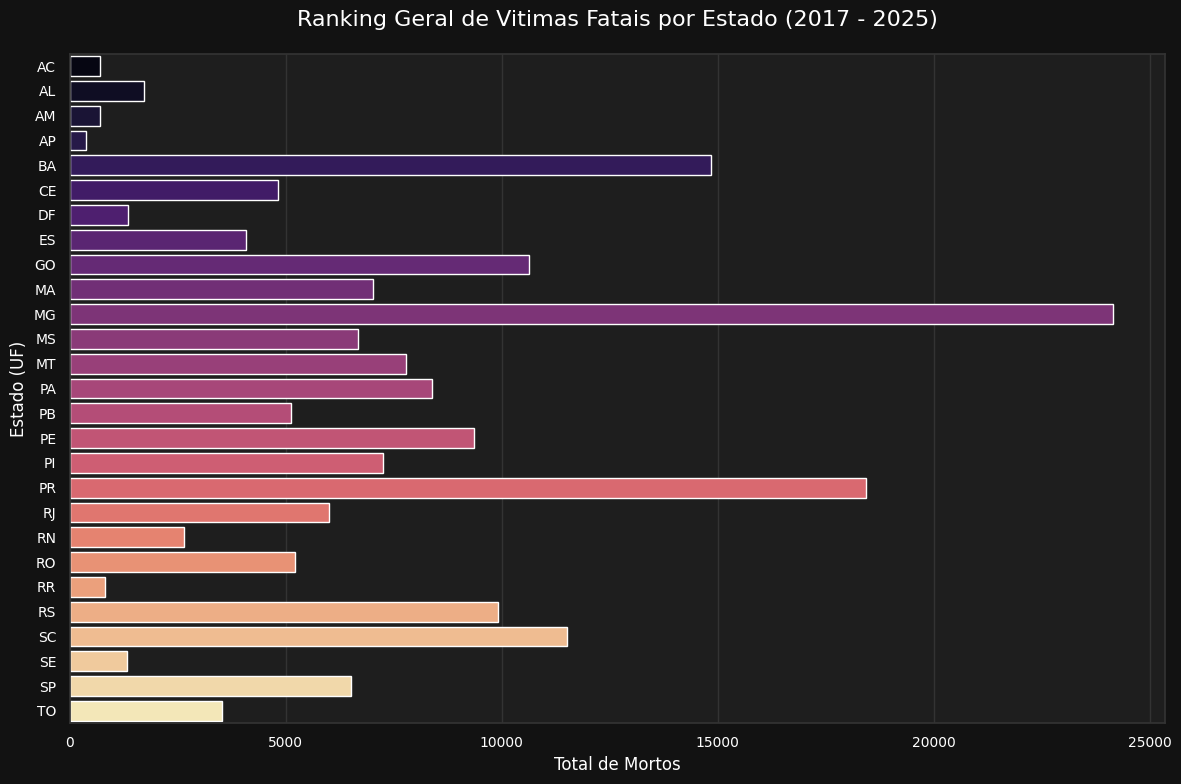

In [11]:
print("\nGerando graficos para o relatorio...")

apply_dark_theme()

# Grafico 1: resultado da consulta do maior corte temporal.
# Como a variavel consulta fica com o ultimo corte do loop anterior, ela representa o limite maximo do dataset.
ranking_completo = consulta.sort_values(by="mortos", ascending=False).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(
    data=ranking_completo,
    x="mortos",
    y="uf",
    hue="uf",
    palette="magma",
    dodge=False,
    legend=False,
)

plt.title("Ranking Geral de Vitimas Fatais por Estado (2017 - 2025)", fontsize=16, color="white", pad=20)
plt.xlabel("Total de Mortos", color="white", fontsize=12)
plt.ylabel("Estado (UF)", color="white", fontsize=12)
plt.tick_params(colors="white", which="both", labelsize=10)

save_report_figure(REPORTS_DIR, "grafico_consulta_estados.png")
plt.show()


**Explicacao do grafico:** Este grafico mostra o ranking geral de vitimas fatais por estado no periodo analisado. Ele ajuda a identificar quais UFs concentram os maiores totais de mortes no dataset.


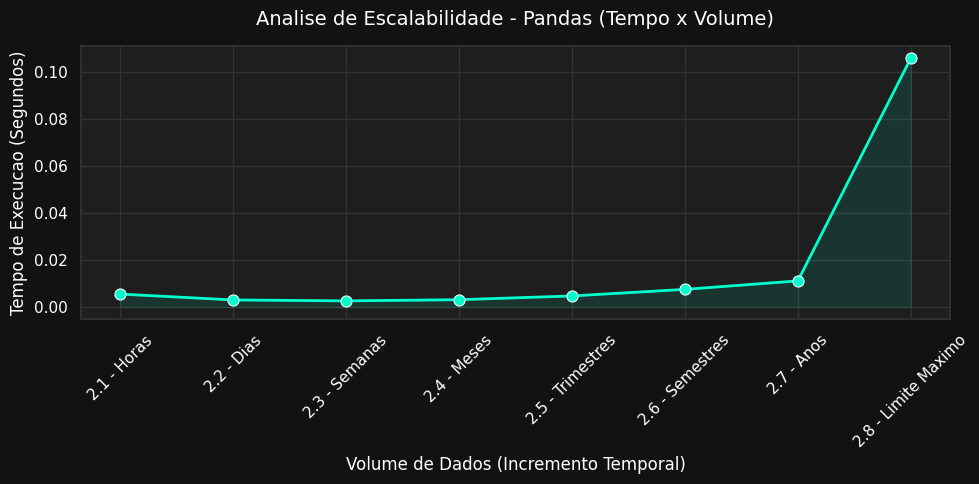

Graficos salvos com sucesso na pasta reports/.


In [12]:
# Grafico 2: escalabilidade do Pandas conforme o volume temporal aumenta.
plt.figure(figsize=(10, 5))

grafico_linha = sns.lineplot(
    data=df_resultados,
    x="Volume",
    y="Tempo_Segundos",
    marker="o",
    color="#00ffcc",
    linewidth=2,
    markersize=8,
)

plt.fill_between(
    df_resultados["Volume"],
    df_resultados["Tempo_Segundos"],
    color="#00ffcc",
    alpha=0.1,
)

plt.title("Analise de Escalabilidade - Pandas (Tempo x Volume)", fontsize=14, color="white", pad=15)
plt.xlabel("Volume de Dados (Incremento Temporal)", color="white")
plt.ylabel("Tempo de Execucao (Segundos)", color="white")
plt.xticks(rotation=45)

save_report_figure(REPORTS_DIR, "grafico_desempenho_pandas.png")
plt.show()

print("Graficos salvos com sucesso na pasta reports/.")


**Explicacao do grafico:** Este grafico mostra como o tempo de execucao do Pandas varia conforme o volume de dados aumenta. A ideia e observar se o crescimento do tempo acompanha o crescimento das linhas processadas.


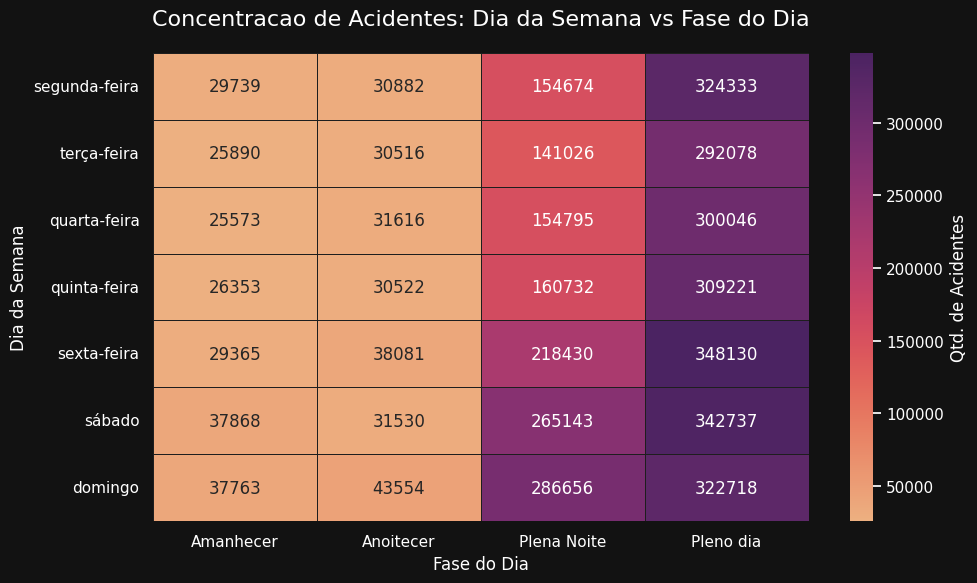

In [13]:
# Grafico 3: heatmap de concentracao por dia da semana e fase do dia.
matriz_dia_fase = df_completo.groupby(["dia_semana", "fase_dia"], observed=True).size().unstack(fill_value=0)

ordem_dias = ["segunda-feira", "terça-feira", "quarta-feira", "quinta-feira", "sexta-feira", "sábado", "domingo"]
ordem_dias = [dia for dia in ordem_dias if dia in matriz_dia_fase.index]
if ordem_dias:
    matriz_dia_fase = matriz_dia_fase.reindex(ordem_dias)

plt.figure(figsize=(10, 6))
sns.heatmap(
    matriz_dia_fase,
    cmap="flare",
    annot=True,
    fmt="d",
    cbar_kws={"label": "Qtd. de Acidentes"},
    linewidths=.5,
    linecolor="#1e1e1e",
)

plt.title("Concentracao de Acidentes: Dia da Semana vs Fase do Dia", fontsize=16, color="white", pad=20)
plt.xlabel("Fase do Dia", color="white", fontsize=12)
plt.ylabel("Dia da Semana", color="white", fontsize=12)
plt.tick_params(colors="white", which="both")

cbar = plt.gca().collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color="white", labelcolor="white")
cbar.set_label("Qtd. de Acidentes", color="white")

save_report_figure(REPORTS_DIR, "grafico_consulta_heatmap.png")
plt.show()


**Explicacao do grafico:** O heatmap cruza dia da semana com fase do dia para mostrar onde ha maior concentracao de acidentes. Cores mais intensas indicam combinacoes com maior quantidade de registros.


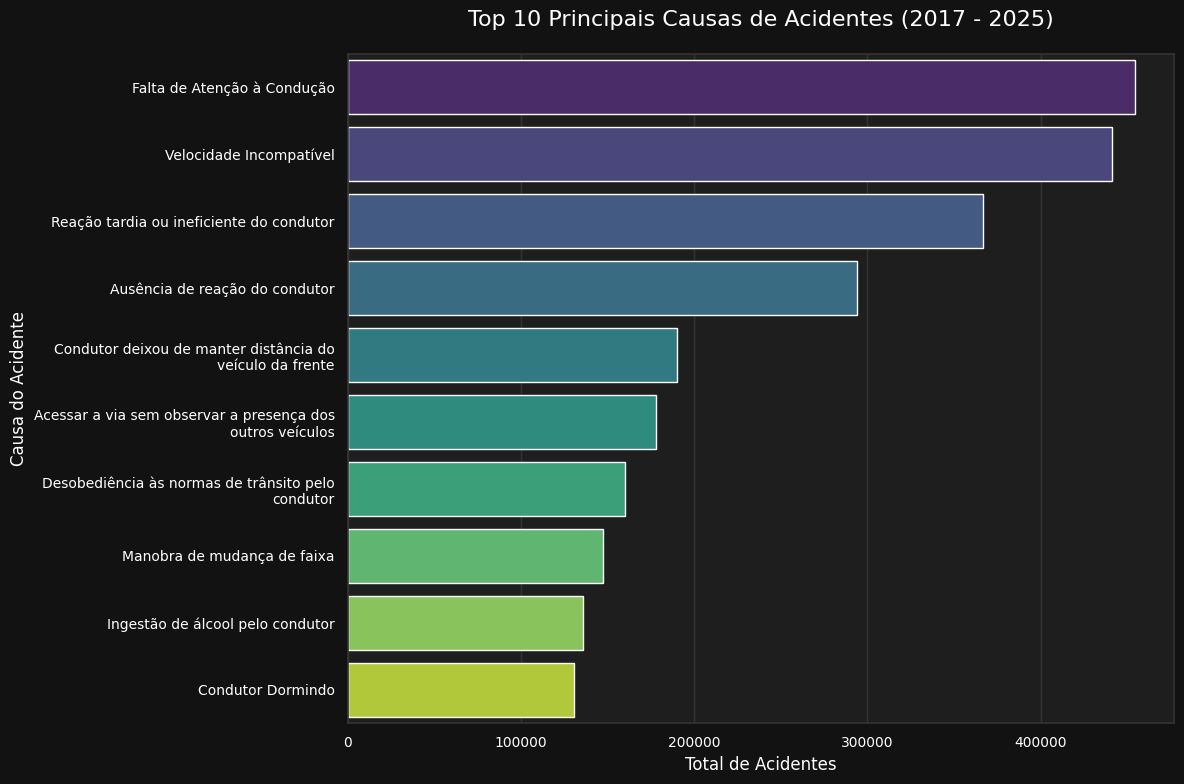

In [14]:
# Grafico 4: top 10 causas mais frequentes de acidentes.
causas = df_completo.groupby("causa_acidente", observed=True).size().reset_index(name="total_acidentes")
top_10_causas = causas.sort_values(by="total_acidentes", ascending=False).head(10)

# Evita categorias vazias no Seaborn e quebra textos longos para melhorar a leitura do eixo Y.
top_10_causas["causa_acidente"] = top_10_causas["causa_acidente"].astype(str)
top_10_causas["causa_acidente"] = top_10_causas["causa_acidente"].apply(lambda x: textwrap.fill(x, width=45))

plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_10_causas,
    x="total_acidentes",
    y="causa_acidente",
    palette="viridis",
    hue="causa_acidente",
    dodge=False,
    legend=False,
)

plt.title("Top 10 Principais Causas de Acidentes (2017 - 2025)", fontsize=16, color="white", pad=20)
plt.xlabel("Total de Acidentes", color="white", fontsize=12)
plt.ylabel("Causa do Acidente", color="white", fontsize=12)
plt.tick_params(colors="white", which="both", labelsize=10)

save_report_figure(REPORTS_DIR, "grafico_consulta_causas.png")
plt.show()


**Explicacao do grafico:** Este grafico apresenta as dez causas de acidente mais frequentes. Ele facilita a leitura dos principais fatores associados aos registros analisados.


## 3 - Comparacao de desempenho entre bibliotecas

O benchmark compara Pandas, Polars, PyArrow e Dask executando a mesma tarefa: leitura dos Parquets, filtro por intervalo de data e agregacao por UF.

Nesta secao, o Dask usa `LocalCluster` para representar a comparacao local entre bibliotecas. A execucao distribuida em cluster externo, com 1, 2 e 3 workers conectados ao scheduler, e tratada separadamente na Parte 4.

A funcao `measure_seconds`, extraida para `src/utils/benchmark.py`, padroniza a medicao de tempo entre as bibliotecas.


In [15]:
# Benchmark local. O Dask entra apenas como comparacao de biblioteca, usando LocalCluster.
cluster = LocalCluster(n_workers=4, threads_per_worker=2)
client = Client(cluster)
print(f"Dask Dashboard disponivel em: {client.dashboard_link}\n")

cortes_tempo = {
    "2.1 - Horas": "2017-01-01 00:59:59",
    "2.2 - Dias": "2017-01-01 23:59:59",
    "2.3 - Semanas": "2017-01-07 23:59:59",
    "2.4 - Meses": "2017-01-31 23:59:59",
    "2.5 - Trimestres": "2017-03-31 23:59:59",
    "2.6 - Semestres": "2017-06-30 23:59:59",
    "2.7 - Anos": "2017-12-31 23:59:59",
    "2.8 - Limite Maximo": "2025-12-31 23:59:59",
}

data_inicial_str = "2017-01-01 00:00:00"
resultados_gerais = []

print("Iniciacao do Benchmark\n")

for nome_corte, data_final_str in cortes_tempo.items():
    print(f"Testando volume: {nome_corte}")

    data_inicial_dt = datetime.strptime(data_inicial_str, "%Y-%m-%d %H:%M:%S")
    data_final_dt = datetime.strptime(data_final_str, "%Y-%m-%d %H:%M:%S")

    # Metodo 1: Pandas.
    def run_pandas():
        df_pd = pd.read_parquet(PARQUET_DIR)
        df_pd["data_inversa"] = pd.to_datetime(df_pd["data_inversa"])
        if "data_hora" not in df_pd.columns:
            df_pd["data_hora"] = pd.to_datetime(
                df_pd["data_inversa"].dt.strftime("%Y-%m-%d") + " " + df_pd["horario"].astype(str),
                errors="coerce",
            )
        df_pd["data_hora"] = pd.to_datetime(df_pd["data_hora"], errors="coerce")
        mask = (df_pd["data_hora"] >= data_inicial_dt) & (df_pd["data_hora"] <= data_final_dt)
        return df_pd[mask].groupby("uf", observed=True)[["mortos", "feridos_graves"]].sum()

    pandas_res, t_pandas = measure_seconds(run_pandas)

    # Metodo 2: Polars com lazy evaluation.
    def run_polars():
        df_pl = pl.scan_parquet(str(PARQUET_DIR / "*.parquet"))
        query_polars = (
            df_pl
            .filter((pl.col("data_hora") >= data_inicial_dt) & (pl.col("data_hora") <= data_final_dt))
            .group_by("uf")
            .agg([pl.col("mortos").sum(), pl.col("feridos_graves").sum()])
        )
        return query_polars.collect()

    polars_res, t_polars = measure_seconds(run_polars)

    # Metodo 3: PyArrow Dataset.
    def run_pyarrow():
        dataset_arrow = ds.dataset(PARQUET_DIR, format="parquet")
        filtro = (pc.field("data_hora") >= data_inicial_dt) & (pc.field("data_hora") <= data_final_dt)
        tabela_filtrada = dataset_arrow.to_table(filter=filtro)
        return tabela_filtrada.group_by("uf").aggregate([("mortos", "sum"), ("feridos_graves", "sum")])

    arrow_res, t_arrow = measure_seconds(run_pyarrow)

    # Metodo 4: Dask local.
    def run_dask():
        df_dd = dd.read_parquet(str(PARQUET_DIR / "*.parquet"))
        if "data_hora" not in df_dd.columns:
            df_dd["data_hora"] = dd.to_datetime(
                df_dd["data_inversa"].astype(str) + " " + df_dd["horario"].astype(str),
                errors="coerce",
            )
        mask_dd = (df_dd["data_hora"] >= data_inicial_str) & (df_dd["data_hora"] <= data_final_str)
        return df_dd[mask_dd].groupby("uf", observed=True)[["mortos", "feridos_graves"]].sum().compute()

    dask_res, t_dask = measure_seconds(run_dask)

    resultados_gerais.append({"Volume": nome_corte, "Biblioteca": "Pandas", "Tempo (s)": t_pandas})
    resultados_gerais.append({"Volume": nome_corte, "Biblioteca": "Polars", "Tempo (s)": t_polars})
    resultados_gerais.append({"Volume": nome_corte, "Biblioteca": "PyArrow", "Tempo (s)": t_arrow})
    resultados_gerais.append({"Volume": nome_corte, "Biblioteca": "Dask", "Tempo (s)": t_dask})

    print(f" -> Pandas: {t_pandas:.4f}s | Polars: {t_polars:.4f}s | PyArrow: {t_arrow:.4f}s | Dask: {t_dask:.4f}s\n")

# Fecha explicitamente o cluster local para liberar recursos ao final do benchmark.
client.close()
cluster.close()


Dask Dashboard disponivel em: http://127.0.0.1:8787/status

Iniciacao do Benchmark

Testando volume: 2.1 - Horas
 -> Pandas: 0.7546s | Polars: 0.2811s | PyArrow: 0.0402s | Dask: 1.3280s

Testando volume: 2.2 - Dias
 -> Pandas: 0.7259s | Polars: 0.0703s | PyArrow: 0.0288s | Dask: 0.3076s

Testando volume: 2.3 - Semanas
 -> Pandas: 0.7232s | Polars: 0.0379s | PyArrow: 0.0270s | Dask: 0.2692s

Testando volume: 2.4 - Meses
 -> Pandas: 0.7190s | Polars: 0.0201s | PyArrow: 0.0292s | Dask: 0.2659s

Testando volume: 2.5 - Trimestres
 -> Pandas: 0.7246s | Polars: 0.0195s | PyArrow: 0.0290s | Dask: 0.2698s

Testando volume: 2.6 - Semestres
 -> Pandas: 0.7378s | Polars: 0.0224s | PyArrow: 0.0331s | Dask: 0.2678s

Testando volume: 2.7 - Anos
 -> Pandas: 0.7475s | Polars: 0.0336s | PyArrow: 0.0312s | Dask: 0.2616s

Testando volume: 2.8 - Limite Maximo
 -> Pandas: 0.7673s | Polars: 0.0970s | PyArrow: 0.2980s | Dask: 0.3330s



In [16]:
# Resumo textual do benchmark entre bibliotecas.
df_resultados_benchmark = pd.DataFrame(resultados_gerais)
df_resumo_benchmark = (
    df_resultados_benchmark
    .groupby("Biblioteca")["Tempo (s)"]
    .agg(tempo_medio_s="mean", menor_tempo_s="min", maior_tempo_s="max")
    .reset_index()
    .sort_values("tempo_medio_s")
)
vencedores_por_volume = (
    df_resultados_benchmark
    .sort_values("Tempo (s)")
    .groupby("Volume", as_index=False)
    .first()[["Volume", "Biblioteca", "Tempo (s)"]]
)

df_resumo_benchmark.to_csv(REPORTS_DIR / "resumo_benchmark_bibliotecas.csv", index=False)
vencedores_por_volume.to_csv(REPORTS_DIR / "vencedores_benchmark_por_volume.csv", index=False)

display(df_resumo_benchmark)
display(vencedores_por_volume)

biblioteca_mais_rapida = df_resumo_benchmark.iloc[0]["Biblioteca"]
tempo_medio_mais_rapido = df_resumo_benchmark.iloc[0]["tempo_medio_s"]
print(
    f"No benchmark executado, {biblioteca_mais_rapida} teve o menor tempo medio "
    f"({tempo_medio_mais_rapido:.4f}s) para a consulta de filtro por data "
    "e agrupamento por UF."
)


,Biblioteca,tempo_medio_s,menor_tempo_s,maior_tempo_s
3,PyArrow,0.064562,0.0270,0.2980
2,Polars,0.072738,0.0195,0.2811
0,Dask,0.412863,0.2616,1.3280
1,Pandas,0.737487,0.7190,0.7673


,Volume,Biblioteca,Tempo (s)
0,2.1 - Horas,PyArrow,0.0402
1,2.2 - Dias,PyArrow,0.0288
2,2.3 - Semanas,PyArrow,0.0270
3,2.4 - Meses,Polars,0.0201
4,2.5 - Trimestres,Polars,0.0195
5,2.6 - Semestres,Polars,0.0224
6,2.7 - Anos,PyArrow,0.0312
7,2.8 - Limite Maximo,Polars,0.0970


No benchmark executado, PyArrow teve o menor tempo medio (0.0646s) para a consulta de filtro por data e agrupamento por UF.


## Grafico comparativo das bibliotecas

O grafico final resume os tempos medidos para cada biblioteca nos diferentes volumes temporais. Ele ajuda a visualizar overhead inicial, escalabilidade e diferencas de abordagem entre execucao ansiosa, lazy evaluation, processamento colunar e agendamento local do Dask.


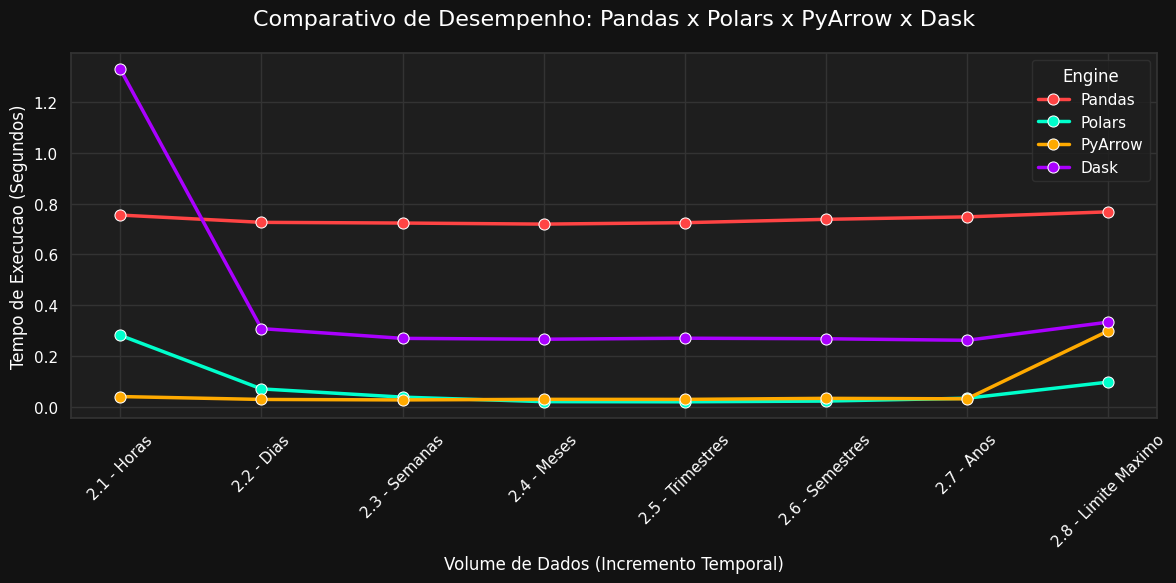

Grafico final salvo em reports/.


In [17]:
df_resultados_benchmark = pd.DataFrame(resultados_gerais)

apply_dark_theme()

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_resultados_benchmark,
    x="Volume",
    y="Tempo (s)",
    hue="Biblioteca",
    marker="o",
    linewidth=2.5,
    markersize=8,
    palette=["#ff4444", "#00ffcc", "#ffaa00", "#aa00ff"],
)

plt.title("Comparativo de Desempenho: Pandas x Polars x PyArrow x Dask", fontsize=16, color="white", pad=20)
plt.xlabel("Volume de Dados (Incremento Temporal)", color="white", fontsize=12)
plt.ylabel("Tempo de Execucao (Segundos)", color="white", fontsize=12)
plt.xticks(rotation=45)
plt.tick_params(colors="white", which="both")

legenda = plt.legend(title="Engine", facecolor="#1e1e1e", edgecolor="#333333")
for text in legenda.get_texts():
    text.set_color("white")
legenda.get_title().set_color("white")

save_report_figure(REPORTS_DIR, "grafico_benchmark_completo.png")
plt.show()

print("Grafico final salvo em reports/.")


**Explicacao do grafico:** Este grafico compara os tempos de execucao das bibliotecas Pandas, Polars, PyArrow e Dask local. Ele resume o comportamento de desempenho de cada ferramenta nos diferentes volumes de dados.


## Insights de desempenho

Os pontos abaixo interpretam os resultados obtidos no benchmark. Eles foram mantidos como apoio para a apresentacao e para a defesa tecnica do trabalho.


- O Polars foi a biblioteca mais rápida em todos os cortes do benchmark registrado. Na consulta de filtro por `data_hora` e agrupamento por `uf`, ele variou de aproximadamente 0,0092s nos menores volumes a 0,0287s no limite máximo do dataset.

- O PyArrow também teve desempenho muito bom por trabalhar diretamente sobre dados colunares: ficou próximo do Polars nos volumes menores, mas no limite máximo subiu para aproximadamente 0,0939s.

- O Dask apresentou maior overhead no primeiro corte por horas (aproximadamente 0,5849s), comportamento esperado por causa da inicialização do agendador e do grafo de tarefas. Depois do primeiro corte, manteve tempos mais estáveis, entre cerca de 0,1563s e 0,2086s, terminando em 0,1833s no limite máximo.

- O Pandas foi a opção mais lenta neste benchmark de leitura + filtro + agrupamento, variando de aproximadamente 0,4616s a 0,6000s. A principal explicação é que ele carrega o conjunto Parquet para a memória de forma ansiosa antes de aplicar a consulta, enquanto Polars e PyArrow conseguem se beneficiar mais do formato colunar.


## 4 - Processamento Paralelo Distribuído (Dask Cluster)

Nesta etapa, a consulta deixa de ser apenas local e passa a ser executada em um cluster Dask distribuido. O scheduler fica acessivel pelo endereco `tcp://10.100.39.211:8786`, enquanto os workers conectados ao cluster executam as tarefas em paralelo.

O experimento mede a mesma consulta de agrupamento no maior volume do dataset: leitura dos arquivos Parquet, filtro pelo intervalo completo de datas e soma de `mortos` e `feridos_graves` por UF. Para avaliar a escalabilidade horizontal, o teste foi repetido em tres cenarios: 1, 2 e 3 workers ativos.

Antes do processamento, cada celula valida se a quantidade esperada de workers esta conectada e se todos conseguem acessar a pasta `dados_otimizados`. Essa verificacao evita comparar tempos de cenarios incompletos ou com algum no sem acesso aos Parquets.

**Pré-requisito:** o `dask-scheduler` e os `dask-workers` devem ser iniciados via terminal nas maquinas fisicas antes da execucao destas celulas, e a pasta `dados_otimizados` deve estar replicada no mesmo caminho em todos os nos.


### Cenario 1: 1 worker ativo

- Scheduler utilizado: `tcp://10.100.39.211:8786`
- Objetivo: registrar o tempo-base do processamento distribuido com apenas um worker.


In [22]:
# Configuracao do experimento distribuido.
# Cada cenario altera apenas CENARIO_WORKERS_ESPERADO para comparar a escalabilidade.
import os
import time
import socket
from pathlib import Path

import pandas as pd
import dask.dataframe as dd
from dask import compute
from dask.distributed import Client

ENDERECO_SCHEDULER = "tcp://10.100.39.211:8786"
CENARIO_WORKERS_ESPERADO = 1

DATA_INICIAL = "2017-01-01 00:00:00"
DATA_FINAL = "2025-12-31 23:59:59"

ARQUIVO_ESCALABILIDADE = REPORTS_DIR / "relatorio_escalabilidade_dask_cluster.csv"


def diagnosticar_worker(parquet_dir: str) -> dict:
    # Esta funcao roda dentro de cada worker para confirmar acesso aos Parquets.
    import os
    import socket
    from pathlib import Path

    caminho = Path(parquet_dir)
    arquivos = list(caminho.glob("*.parquet")) if caminho.exists() else []

    return {
        "host": socket.gethostname(),
        "pid": os.getpid(),
        "cwd": os.getcwd(),
        "parquet_dir": str(caminho),
        "parquet_dir_existe": caminho.exists(),
        "qtd_parquets": len(arquivos),
    }


print("Conectando ao cluster Dask distribuido...")

client = Client(ENDERECO_SCHEDULER)

try:
    # Aguarda exatamente o numero de workers esperado para este cenario.
    client.wait_for_workers(CENARIO_WORKERS_ESPERADO, timeout=60)

    info_cluster = client.scheduler_info()
    workers = info_cluster.get("workers", {})

    workers_ativos = len(workers)
    threads_ativas = sum(w.get("nthreads", 0) for w in workers.values())
    memoria_total_gb = sum(w.get("memory_limit", 0) for w in workers.values()) / (1024 ** 3)

    print(f"Workers ativos: {workers_ativos}")
    print(f"Threads ativas: {threads_ativas}")
    print(f"Memoria total informada pelos workers: {memoria_total_gb:.2f} GB")
    print(f"Dashboard: {client.dashboard_link}")

    if workers_ativos != CENARIO_WORKERS_ESPERADO:
        raise RuntimeError(
            f"O cenario esperado era {CENARIO_WORKERS_ESPERADO} worker(s), "
            f"mas o cluster possui {workers_ativos} worker(s) ativo(s)."
        )

    # Diagnostico distribuido: cada worker confirma host, processo e visibilidade dos arquivos.
    diagnosticos = client.run(diagnosticar_worker, str(PARQUET_DIR))

    df_diagnostico = (
        pd.DataFrame.from_dict(diagnosticos, orient="index")
        .reset_index()
        .rename(columns={"index": "worker_address"})
    )

    display(df_diagnostico)

    if not df_diagnostico["parquet_dir_existe"].all():
        raise FileNotFoundError(
            "Pelo menos um worker nao encontrou a pasta dos Parquets."
        )

    if (df_diagnostico["qtd_parquets"] == 0).any():
        raise FileNotFoundError(
            "Pelo menos um worker encontrou a pasta, mas nao encontrou arquivos .parquet."
        )

    hosts = sorted(df_diagnostico["host"].unique())

    # A medicao comeca depois das validacoes, para focar no custo da consulta distribuida.
    t0 = time.perf_counter()

    df_dask = dd.read_parquet(str(PARQUET_DIR / "*.parquet"), engine="pyarrow")

    # Garante a coluna temporal usada no filtro, mesmo se algum Parquet antigo nao tiver data_hora.
    if "data_hora" not in df_dask.columns:
        df_dask["data_hora"] = dd.to_datetime(
            df_dask["data_inversa"].astype(str) + " " + df_dask["horario"].astype(str),
            errors="coerce",
        )
    else:
        df_dask["data_hora"] = dd.to_datetime(df_dask["data_hora"], errors="coerce")

    data_inicial = pd.Timestamp(DATA_INICIAL)
    data_final = pd.Timestamp(DATA_FINAL)

    df_filtrado = df_dask[
        (df_dask["data_hora"] >= data_inicial)
        & (df_dask["data_hora"] <= data_final)
    ]

    # Consulta principal: total de mortos e feridos graves por unidade federativa.
    consulta_uf = (
        df_filtrado
        .groupby("uf", observed=True)[["mortos", "feridos_graves"]]
        .sum()
    )

    total_linhas = df_filtrado.shape[0]

    # compute dispara as tarefas no cluster para agregacao e contagem de linhas.
    resultado_dask, linhas_processadas = compute(consulta_uf, total_linhas)

    tempo_total = round(time.perf_counter() - t0, 4)

    resultado_dask = resultado_dask.sort_index()

    print(f"Processamento concluido em {tempo_total} segundos.")
    print(f"Linhas processadas: {linhas_processadas:,}".replace(",", "."))

    display(resultado_dask)

    # Salva o resultado agregado do cenario para comparacao posterior entre workers.
    arquivo_resultado_uf = REPORTS_DIR / f"resultado_dask_cluster_{CENARIO_WORKERS_ESPERADO}_workers.csv"
    resultado_dask.to_csv(arquivo_resultado_uf)

    registro = pd.DataFrame([{
        "Data_Teste": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"),
        "Cenario_Workers_Esperado": CENARIO_WORKERS_ESPERADO,
        "Workers_Ativos": workers_ativos,
        "Threads_Ativas": threads_ativas,
        "Memoria_Total_GB": round(memoria_total_gb, 2),
        "Hosts": ", ".join(hosts),
        "Linhas_Processadas": int(linhas_processadas),
        "Tempo_Segundos": tempo_total,
        "Scheduler": ENDERECO_SCHEDULER,
    }])

    # O relatorio e acumulativo para preservar tentativas e permitir escolher o ultimo teste valido.
    if ARQUIVO_ESCALABILIDADE.exists():
        registro.to_csv(ARQUIVO_ESCALABILIDADE, mode="a", header=False, index=False)
    else:
        registro.to_csv(ARQUIVO_ESCALABILIDADE, index=False)

    print(f"Relatorio salvo em: {ARQUIVO_ESCALABILIDADE}")
    print(f"Resultado por UF salvo em: {arquivo_resultado_uf}")

    df_escalabilidade = pd.read_csv(ARQUIVO_ESCALABILIDADE)
    display(df_escalabilidade.tail(10))

finally:
    # Fecha a conexao com o scheduler sem interromper o cluster externo.
    client.close()

Conectando ao cluster Dask distribuido...
Workers ativos: 1
Threads ativas: 2
Memoria total informada pelos workers: 7.75 GB
Dashboard: http://10.100.39.211:8787/status


,worker_address,host,pid,cwd,parquet_dir,parquet_dir_existe,qtd_parquets
0,tcp://10.100.39.211:35585,zorin,54809,/home/aluno,/home/aluno/Downloads/pad_acidentes_prf-main/d...,True,9


Processamento concluido em 3.0141 segundos.
Linhas processadas: 4.069.971


,mortos,feridos_graves
uf,,
AC,700,1992
AL,1728,4398
AM,696,1203
AP,385,1426
BA,14850,27056
CE,4818,12354
DF,1345,4818
ES,4079,16191
GO,10627,23569


Relatorio salvo em: /home/aluno/Downloads/pad_acidentes_prf-main/reports/relatorio_escalabilidade_dask_cluster.csv
Resultado por UF salvo em: /home/aluno/Downloads/pad_acidentes_prf-main/reports/resultado_dask_cluster_1_workers.csv


,Data_Teste,Cenario_Workers_Esperado,Workers_Ativos,Threads_Ativas,Memoria_Total_GB,Hosts,Linhas_Processadas,Tempo_Segundos,Scheduler
0,2026-05-06 17:43:17,1,1,2,7.75,zorin,4069971,3.0141,tcp://10.100.39.211:8786


### Cenario 2: 2 workers ativos

- Scheduler utilizado: `tcp://10.100.39.211:8786`
- Objetivo: medir o ganho ao dobrar a quantidade de workers disponiveis.


In [31]:
# Configuracao do experimento distribuido.
# Cada cenario altera apenas CENARIO_WORKERS_ESPERADO para comparar a escalabilidade.
import os
import time
import socket
from pathlib import Path

import pandas as pd
import dask.dataframe as dd
from dask import compute
from dask.distributed import Client

ENDERECO_SCHEDULER = "tcp://10.100.39.211:8786"
CENARIO_WORKERS_ESPERADO = 2

DATA_INICIAL = "2017-01-01 00:00:00"
DATA_FINAL = "2025-12-31 23:59:59"

ARQUIVO_ESCALABILIDADE = REPORTS_DIR / "relatorio_escalabilidade_dask_cluster.csv"


def diagnosticar_worker(parquet_dir: str) -> dict:
    # Esta funcao roda dentro de cada worker para confirmar acesso aos Parquets.
    import os
    import socket
    from pathlib import Path

    caminho = Path(parquet_dir)
    arquivos = list(caminho.glob("*.parquet")) if caminho.exists() else []

    return {
        "host": socket.gethostname(),
        "pid": os.getpid(),
        "cwd": os.getcwd(),
        "parquet_dir": str(caminho),
        "parquet_dir_existe": caminho.exists(),
        "qtd_parquets": len(arquivos),
    }


print("Conectando ao cluster Dask distribuido...")

client = Client(ENDERECO_SCHEDULER)

try:
    # Aguarda exatamente o numero de workers esperado para este cenario.
    client.wait_for_workers(CENARIO_WORKERS_ESPERADO, timeout=60)

    info_cluster = client.scheduler_info()
    workers = info_cluster.get("workers", {})

    workers_ativos = len(workers)
    threads_ativas = sum(w.get("nthreads", 0) for w in workers.values())
    memoria_total_gb = sum(w.get("memory_limit", 0) for w in workers.values()) / (1024 ** 3)

    print(f"Workers ativos: {workers_ativos}")
    print(f"Threads ativas: {threads_ativas}")
    print(f"Memoria total informada pelos workers: {memoria_total_gb:.2f} GB")
    print(f"Dashboard: {client.dashboard_link}")

    if workers_ativos != CENARIO_WORKERS_ESPERADO:
        raise RuntimeError(
            f"O cenario esperado era {CENARIO_WORKERS_ESPERADO} worker(s), "
            f"mas o cluster possui {workers_ativos} worker(s) ativo(s)."
        )

    # Diagnostico distribuido: cada worker confirma host, processo e visibilidade dos arquivos.
    diagnosticos = client.run(diagnosticar_worker, str(PARQUET_DIR))

    df_diagnostico = (
        pd.DataFrame.from_dict(diagnosticos, orient="index")
        .reset_index()
        .rename(columns={"index": "worker_address"})
    )

    display(df_diagnostico)

    if not df_diagnostico["parquet_dir_existe"].all():
        raise FileNotFoundError(
            "Pelo menos um worker nao encontrou a pasta dos Parquets."
        )

    if (df_diagnostico["qtd_parquets"] == 0).any():
        raise FileNotFoundError(
            "Pelo menos um worker encontrou a pasta, mas nao encontrou arquivos .parquet."
        )

    hosts = sorted(df_diagnostico["host"].unique())

    # A medicao comeca depois das validacoes, para focar no custo da consulta distribuida.
    t0 = time.perf_counter()

    df_dask = dd.read_parquet(str(PARQUET_DIR / "*.parquet"), engine="pyarrow")

    # Garante a coluna temporal usada no filtro, mesmo se algum Parquet antigo nao tiver data_hora.
    if "data_hora" not in df_dask.columns:
        df_dask["data_hora"] = dd.to_datetime(
            df_dask["data_inversa"].astype(str) + " " + df_dask["horario"].astype(str),
            errors="coerce",
        )
    else:
        df_dask["data_hora"] = dd.to_datetime(df_dask["data_hora"], errors="coerce")

    data_inicial = pd.Timestamp(DATA_INICIAL)
    data_final = pd.Timestamp(DATA_FINAL)

    df_filtrado = df_dask[
        (df_dask["data_hora"] >= data_inicial)
        & (df_dask["data_hora"] <= data_final)
    ]

    # Consulta principal: total de mortos e feridos graves por unidade federativa.
    consulta_uf = (
        df_filtrado
        .groupby("uf", observed=True)[["mortos", "feridos_graves"]]
        .sum()
    )

    total_linhas = df_filtrado.shape[0]

    # compute dispara as tarefas no cluster para agregacao e contagem de linhas.
    resultado_dask, linhas_processadas = compute(consulta_uf, total_linhas)

    tempo_total = round(time.perf_counter() - t0, 4)

    resultado_dask = resultado_dask.sort_index()

    print(f"Processamento concluido em {tempo_total} segundos.")
    print(f"Linhas processadas: {linhas_processadas:,}".replace(",", "."))

    display(resultado_dask)

    # Salva o resultado agregado do cenario para comparacao posterior entre workers.
    arquivo_resultado_uf = REPORTS_DIR / f"resultado_dask_cluster_{CENARIO_WORKERS_ESPERADO}_workers.csv"
    resultado_dask.to_csv(arquivo_resultado_uf)

    registro = pd.DataFrame([{
        "Data_Teste": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"),
        "Cenario_Workers_Esperado": CENARIO_WORKERS_ESPERADO,
        "Workers_Ativos": workers_ativos,
        "Threads_Ativas": threads_ativas,
        "Memoria_Total_GB": round(memoria_total_gb, 2),
        "Hosts": ", ".join(hosts),
        "Linhas_Processadas": int(linhas_processadas),
        "Tempo_Segundos": tempo_total,
        "Scheduler": ENDERECO_SCHEDULER,
    }])

    # O relatorio e acumulativo para preservar tentativas e permitir escolher o ultimo teste valido.
    if ARQUIVO_ESCALABILIDADE.exists():
        registro.to_csv(ARQUIVO_ESCALABILIDADE, mode="a", header=False, index=False)
    else:
        registro.to_csv(ARQUIVO_ESCALABILIDADE, index=False)

    print(f"Relatorio salvo em: {ARQUIVO_ESCALABILIDADE}")
    print(f"Resultado por UF salvo em: {arquivo_resultado_uf}")

    df_escalabilidade = pd.read_csv(ARQUIVO_ESCALABILIDADE)
    display(df_escalabilidade.tail(10))

finally:
    # Fecha a conexao com o scheduler sem interromper o cluster externo.
    client.close()

Conectando ao cluster Dask distribuido...
Workers ativos: 2
Threads ativas: 4
Memoria total informada pelos workers: 15.51 GB
Dashboard: http://10.100.39.211:8787/status


,worker_address,host,pid,cwd,parquet_dir,parquet_dir_existe,qtd_parquets
0,tcp://10.100.39.210:39515,zorin,31214,/home/aluno,/home/aluno/Downloads/pad_acidentes_prf-main/d...,True,9
1,tcp://10.100.39.211:41457,zorin,57137,/home/aluno,/home/aluno/Downloads/pad_acidentes_prf-main/d...,True,9


Processamento concluido em 1.5147 segundos.
Linhas processadas: 4.069.971


,mortos,feridos_graves
uf,,
AC,700,1992
AL,1728,4398
AM,696,1203
AP,385,1426
BA,14850,27056
CE,4818,12354
DF,1345,4818
ES,4079,16191
GO,10627,23569


Relatorio salvo em: /home/aluno/Downloads/pad_acidentes_prf-main/reports/relatorio_escalabilidade_dask_cluster.csv
Resultado por UF salvo em: /home/aluno/Downloads/pad_acidentes_prf-main/reports/resultado_dask_cluster_2_workers.csv


,Data_Teste,Cenario_Workers_Esperado,Workers_Ativos,Threads_Ativas,Memoria_Total_GB,Hosts,Linhas_Processadas,Tempo_Segundos,Scheduler
0,2026-05-06 17:43:17,1,1,2,7.75,zorin,4069971,3.0141,tcp://10.100.39.211:8786
1,2026-05-06 18:14:49,2,2,4,15.51,zorin,4069971,1.4867,tcp://10.100.39.211:8786
2,2026-05-06 18:17:44,2,2,4,15.51,zorin,4069971,1.4184,tcp://10.100.39.211:8786
3,2026-05-06 18:19:54,2,2,4,15.51,zorin,4069971,1.4241,tcp://10.100.39.211:8786
4,2026-05-06 18:23:30,2,2,4,15.51,zorin,4069971,1.7598,tcp://10.100.39.211:8786
5,2026-05-06 18:27:54,2,2,4,15.51,zorin,4069971,2.4482,tcp://10.100.39.211:8786
6,2026-05-06 18:38:16,2,2,4,15.51,zorin,4069971,1.5147,tcp://10.100.39.211:8786


### Cenario 3: 3 workers ativos

- Scheduler utilizado: `tcp://10.100.39.211:8786`
- Objetivo: observar se o tempo continua reduzindo com mais um worker no cluster.


In [39]:
# Configuracao do experimento distribuido.
# Cada cenario altera apenas CENARIO_WORKERS_ESPERADO para comparar a escalabilidade.
import os
import time
import socket
from pathlib import Path

import pandas as pd
import dask.dataframe as dd
from dask import compute
from dask.distributed import Client

ENDERECO_SCHEDULER = "tcp://10.100.39.211:8786"
CENARIO_WORKERS_ESPERADO = 3

DATA_INICIAL = "2017-01-01 00:00:00"
DATA_FINAL = "2025-12-31 23:59:59"

ARQUIVO_ESCALABILIDADE = REPORTS_DIR / "relatorio_escalabilidade_dask_cluster.csv"


def diagnosticar_worker(parquet_dir: str) -> dict:
    # Esta funcao roda dentro de cada worker para confirmar acesso aos Parquets.
    import os
    import socket
    from pathlib import Path

    caminho = Path(parquet_dir)
    arquivos = list(caminho.glob("*.parquet")) if caminho.exists() else []

    return {
        "host": socket.gethostname(),
        "pid": os.getpid(),
        "cwd": os.getcwd(),
        "parquet_dir": str(caminho),
        "parquet_dir_existe": caminho.exists(),
        "qtd_parquets": len(arquivos),
    }


print("Conectando ao cluster Dask distribuido...")

client = Client(ENDERECO_SCHEDULER)

try:
    # Aguarda exatamente o numero de workers esperado para este cenario.
    client.wait_for_workers(CENARIO_WORKERS_ESPERADO, timeout=60)

    info_cluster = client.scheduler_info()
    workers = info_cluster.get("workers", {})

    workers_ativos = len(workers)
    threads_ativas = sum(w.get("nthreads", 0) for w in workers.values())
    memoria_total_gb = sum(w.get("memory_limit", 0) for w in workers.values()) / (1024 ** 3)

    print(f"Workers ativos: {workers_ativos}")
    print(f"Threads ativas: {threads_ativas}")
    print(f"Memoria total informada pelos workers: {memoria_total_gb:.2f} GB")
    print(f"Dashboard: {client.dashboard_link}")

    if workers_ativos != CENARIO_WORKERS_ESPERADO:
        raise RuntimeError(
            f"O cenario esperado era {CENARIO_WORKERS_ESPERADO} worker(s), "
            f"mas o cluster possui {workers_ativos} worker(s) ativo(s)."
        )

    # Diagnostico distribuido: cada worker confirma host, processo e visibilidade dos arquivos.
    diagnosticos = client.run(diagnosticar_worker, str(PARQUET_DIR))

    df_diagnostico = (
        pd.DataFrame.from_dict(diagnosticos, orient="index")
        .reset_index()
        .rename(columns={"index": "worker_address"})
    )

    display(df_diagnostico)

    if not df_diagnostico["parquet_dir_existe"].all():
        raise FileNotFoundError(
            "Pelo menos um worker nao encontrou a pasta dos Parquets."
        )

    if (df_diagnostico["qtd_parquets"] == 0).any():
        raise FileNotFoundError(
            "Pelo menos um worker encontrou a pasta, mas nao encontrou arquivos .parquet."
        )

    hosts = sorted(df_diagnostico["host"].unique())

    # A medicao comeca depois das validacoes, para focar no custo da consulta distribuida.
    t0 = time.perf_counter()

    df_dask = dd.read_parquet(str(PARQUET_DIR / "*.parquet"), engine="pyarrow")

    # Garante a coluna temporal usada no filtro, mesmo se algum Parquet antigo nao tiver data_hora.
    if "data_hora" not in df_dask.columns:
        df_dask["data_hora"] = dd.to_datetime(
            df_dask["data_inversa"].astype(str) + " " + df_dask["horario"].astype(str),
            errors="coerce",
        )
    else:
        df_dask["data_hora"] = dd.to_datetime(df_dask["data_hora"], errors="coerce")

    data_inicial = pd.Timestamp(DATA_INICIAL)
    data_final = pd.Timestamp(DATA_FINAL)

    df_filtrado = df_dask[
        (df_dask["data_hora"] >= data_inicial)
        & (df_dask["data_hora"] <= data_final)
    ]

    # Consulta principal: total de mortos e feridos graves por unidade federativa.
    consulta_uf = (
        df_filtrado
        .groupby("uf", observed=True)[["mortos", "feridos_graves"]]
        .sum()
    )

    total_linhas = df_filtrado.shape[0]

    # compute dispara as tarefas no cluster para agregacao e contagem de linhas.
    resultado_dask, linhas_processadas = compute(consulta_uf, total_linhas)

    tempo_total = round(time.perf_counter() - t0, 4)

    resultado_dask = resultado_dask.sort_index()

    print(f"Processamento concluido em {tempo_total} segundos.")
    print(f"Linhas processadas: {linhas_processadas:,}".replace(",", "."))

    display(resultado_dask)

    # Salva o resultado agregado do cenario para comparacao posterior entre workers.
    arquivo_resultado_uf = REPORTS_DIR / f"resultado_dask_cluster_{CENARIO_WORKERS_ESPERADO}_workers.csv"
    resultado_dask.to_csv(arquivo_resultado_uf)

    registro = pd.DataFrame([{
        "Data_Teste": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"),
        "Cenario_Workers_Esperado": CENARIO_WORKERS_ESPERADO,
        "Workers_Ativos": workers_ativos,
        "Threads_Ativas": threads_ativas,
        "Memoria_Total_GB": round(memoria_total_gb, 2),
        "Hosts": ", ".join(hosts),
        "Linhas_Processadas": int(linhas_processadas),
        "Tempo_Segundos": tempo_total,
        "Scheduler": ENDERECO_SCHEDULER,
    }])

    # O relatorio e acumulativo para preservar tentativas e permitir escolher o ultimo teste valido.
    if ARQUIVO_ESCALABILIDADE.exists():
        registro.to_csv(ARQUIVO_ESCALABILIDADE, mode="a", header=False, index=False)
    else:
        registro.to_csv(ARQUIVO_ESCALABILIDADE, index=False)

    print(f"Relatorio salvo em: {ARQUIVO_ESCALABILIDADE}")
    print(f"Resultado por UF salvo em: {arquivo_resultado_uf}")

    df_escalabilidade = pd.read_csv(ARQUIVO_ESCALABILIDADE)
    display(df_escalabilidade.tail(10))

finally:
    # Fecha a conexao com o scheduler sem interromper o cluster externo.
    client.close()

Conectando ao cluster Dask distribuido...
Workers ativos: 3
Threads ativas: 6
Memoria total informada pelos workers: 23.26 GB
Dashboard: http://10.100.39.211:8787/status


,worker_address,host,pid,cwd,parquet_dir,parquet_dir_existe,qtd_parquets
0,tcp://10.100.39.210:44087,zorin,31398,/home/aluno,/home/aluno/Downloads/pad_acidentes_prf-main/d...,True,9
1,tcp://10.100.39.211:40237,zorin,58600,/home/aluno,/home/aluno/Downloads/pad_acidentes_prf-main/d...,True,9
2,tcp://10.100.39.212:36121,zorin,18736,/home/aluno,/home/aluno/Downloads/pad_acidentes_prf-main/d...,True,9


Processamento concluido em 1.4024 segundos.
Linhas processadas: 4.069.971


,mortos,feridos_graves
uf,,
AC,700,1992
AL,1728,4398
AM,696,1203
AP,385,1426
BA,14850,27056
CE,4818,12354
DF,1345,4818
ES,4079,16191
GO,10627,23569


Relatorio salvo em: /home/aluno/Downloads/pad_acidentes_prf-main/reports/relatorio_escalabilidade_dask_cluster.csv
Resultado por UF salvo em: /home/aluno/Downloads/pad_acidentes_prf-main/reports/resultado_dask_cluster_3_workers.csv


,Data_Teste,Cenario_Workers_Esperado,Workers_Ativos,Threads_Ativas,Memoria_Total_GB,Hosts,Linhas_Processadas,Tempo_Segundos,Scheduler
3,2026-05-06 18:19:54,2,2,4,15.51,zorin,4069971,1.4241,tcp://10.100.39.211:8786
4,2026-05-06 18:23:30,2,2,4,15.51,zorin,4069971,1.7598,tcp://10.100.39.211:8786
5,2026-05-06 18:27:54,2,2,4,15.51,zorin,4069971,2.4482,tcp://10.100.39.211:8786
6,2026-05-06 18:38:16,2,2,4,15.51,zorin,4069971,1.5147,tcp://10.100.39.211:8786
7,2026-05-06 18:42:30,3,3,6,23.26,zorin,4069971,2.2453,tcp://10.100.39.211:8786
8,2026-05-06 18:43:53,3,3,6,23.26,zorin,4069971,1.4728,tcp://10.100.39.211:8786
9,2026-05-06 18:51:46,3,3,6,23.26,zorin,4069971,2.4353,tcp://10.100.39.211:8786
10,2026-05-06 18:55:45,3,3,6,23.26,zorin,4069971,1.4367,tcp://10.100.39.211:8786
11,2026-05-06 18:56:05,3,3,6,23.26,zorin,4069971,1.3804,tcp://10.100.39.211:8786
12,2026-05-06 18:56:21,3,3,6,23.26,zorin,4069971,1.4024,tcp://10.100.39.211:8786


### Comparação dos cenários

A comparacao usa o ultimo registro salvo para cada quantidade de workers, mantendo a mesma consulta e o mesmo volume de dados. O grafico final resume a relacao entre o numero de workers ativos e o tempo total registrado.


,Data_Teste,Cenario_Workers_Esperado,Workers_Ativos,Threads_Ativas,Memoria_Total_GB,Hosts,Linhas_Processadas,Tempo_Segundos,Scheduler
0,2026-05-06 17:43:17,1,1,2,7.75,zorin,4069971,3.0141,tcp://10.100.39.211:8786
6,2026-05-06 18:38:16,2,2,4,15.51,zorin,4069971,1.5147,tcp://10.100.39.211:8786
12,2026-05-06 18:56:21,3,3,6,23.26,zorin,4069971,1.4024,tcp://10.100.39.211:8786


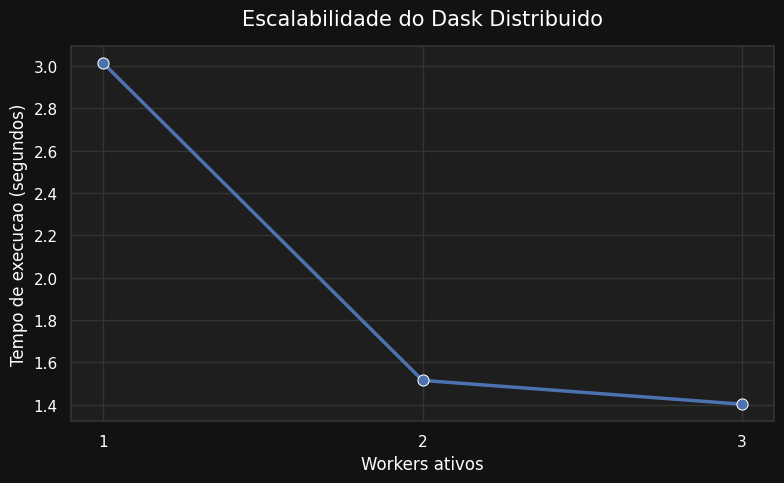

Grafico de escalabilidade salvo em reports/.


In [40]:
# Consolida os registros salvos pelos cenarios distribuídos.
arquivo_escalabilidade = REPORTS_DIR / "relatorio_escalabilidade_dask_cluster.csv"

if not arquivo_escalabilidade.exists():
    print("Ainda nao existe relatorio de escalabilidade.")
else:
    df_escalabilidade = pd.read_csv(arquivo_escalabilidade)

    # Usa o ultimo registro de cada cenario para comparar execucoes equivalentes.
    df_plot = (
        df_escalabilidade
        .drop_duplicates(subset=["Cenario_Workers_Esperado"], keep="last")
        .sort_values("Cenario_Workers_Esperado")
    )

    display(df_plot)

    apply_dark_theme()

    # O grafico evidencia a variacao do tempo conforme o cluster ganha workers.
    plt.figure(figsize=(8, 5))
    sns.lineplot(
        data=df_plot,
        x="Cenario_Workers_Esperado",
        y="Tempo_Segundos",
        marker="o",
        linewidth=2.5,
        markersize=8,
    )

    plt.title("Escalabilidade do Dask Distribuido", fontsize=15, color="white", pad=15)
    plt.xlabel("Workers ativos", color="white")
    plt.ylabel("Tempo de execucao (segundos)", color="white")
    plt.xticks([1, 2, 3])
    plt.tick_params(colors="white", which="both")

    save_report_figure(REPORTS_DIR, "grafico_escalabilidade_dask_cluster.png")
    plt.show()

    print("Grafico de escalabilidade salvo em reports/.")

## Referencias e fontes

- Dataset: Policia Rodoviaria Federal (PRF), Dados Abertos da PRF, base BAT - Boletim de Acidente de Transito. Foram usados os documentos CSV de Acidentes de 2017 a 2025, agrupados por pessoa, com todas as causas e tipos de acidentes: https://www.gov.br/prf/pt-br/acesso-a-informacao/dados-abertos/dados-abertos-da-prf
- Dicionario de dados de acidentes da PRF: disponivel na mesma pagina de Dados Abertos da PRF, item `Dicionario de Dados - Acidentes`.
- Pandas: https://pandas.pydata.org/docs/
- PyArrow: https://arrow.apache.org/docs/python/
- Polars: https://docs.pola.rs/
- Dask e Dask Distributed: https://docs.dask.org/ e https://distributed.dask.org/
- Matplotlib: https://matplotlib.org/stable/contents.html
- Seaborn: https://seaborn.pydata.org/
- Jupyter Notebook: https://docs.jupyter.org/
- Apoio de IA: utilizado para revisao estrutural, documentacao, organizacao do projeto e melhoria textual, sem substituicao da interpretacao tecnica dos autores.
